# Hidden Markov Models


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from scipy.special import logsumexp
from copy import deepcopy
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

---
## 1. Why HMMs? — The Dishonest Casino

A casino dealer secretly switches between a **fair die** and a **loaded die**. We only see the rolls $x_t$, not which die $z_t$ is in use.

- $z_t \in \{\text{Fair}, \text{Loaded}\}$, $\;x_t \in \{1,2,3,4,5,6\}$
- Fair die: uniform $p(x_t|z_t=F) = 1/6$
- Loaded die: $p(x_t=6|z_t=L) = 0.5$, others $= 0.1$

A first-order Markov chain on $x_t$ alone cannot capture this — the **hidden state** $z_t$ induces long-range dependencies in the observations.

$$x_i \not\perp x_j \mid z \quad \text{(marginally dependent through the latent chain)}$$

In [2]:
# States: 0 = Fair, 1 = Loaded
A_casino = np.array([[0.95, 0.05],
                     [0.10, 0.90]])

pi_casino = np.array([0.5, 0.5])

# Emission: p(x | z), rows = states, cols = die faces 1..6
B_casino = np.array([[1/6]*6,
                      [0.1, 0.1, 0.1, 0.1, 0.1, 0.5]])

In [3]:
def simulate_hmm(A, pi, B, T):
    """Simulate from a discrete-emission HMM.
    Returns: states (T,), observations (T,)
    """
    K = len(pi)
    states = np.zeros(T, dtype=int)
    obs = np.zeros(T, dtype=int)
    states[0] = np.random.choice(K, p=pi)
    obs[0] = np.random.choice(B.shape[1], p=B[states[0]])
    for t in range(1, T):
        states[t] = np.random.choice(K, p=A[states[t-1]])
        obs[t] = np.random.choice(B.shape[1], p=B[states[t]])
    return states, obs

T = 300
true_states, observations = simulate_hmm(A_casino, pi_casino, B_casino, T)

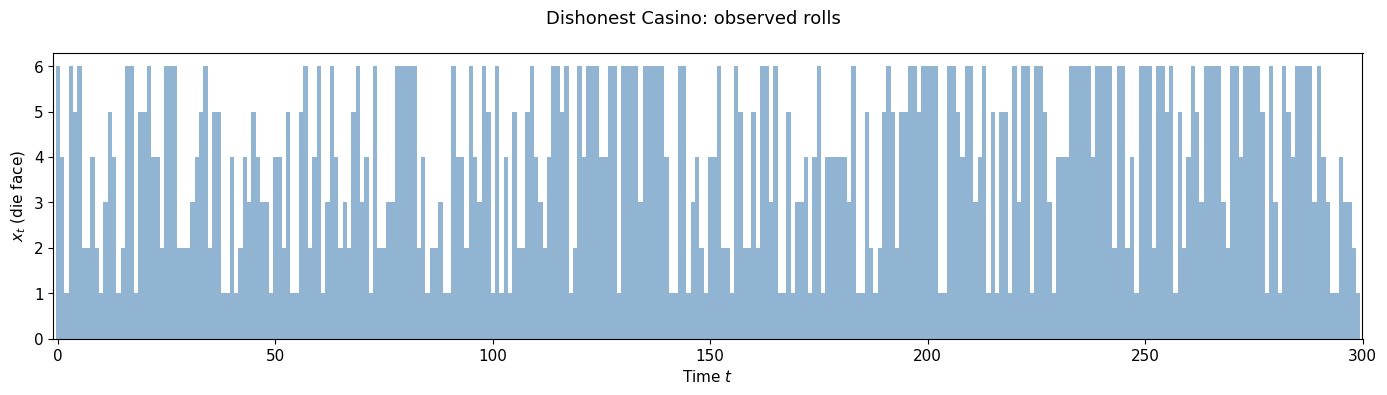

In [4]:
# Visualize: observations
fig, ax = plt.subplots(1, 1, figsize=(14, 4), sharex=True)
ax.bar(range(T), observations+1, width=1.0, color='steelblue', alpha=0.6)
ax.set_ylabel('$x_t$ (die face)')
ax.set_xlabel('Time $t$')
ax.set_xlim(-1, T)
fig.suptitle('Dishonest Casino: observed rolls', fontsize=13)
plt.tight_layout()
plt.show()

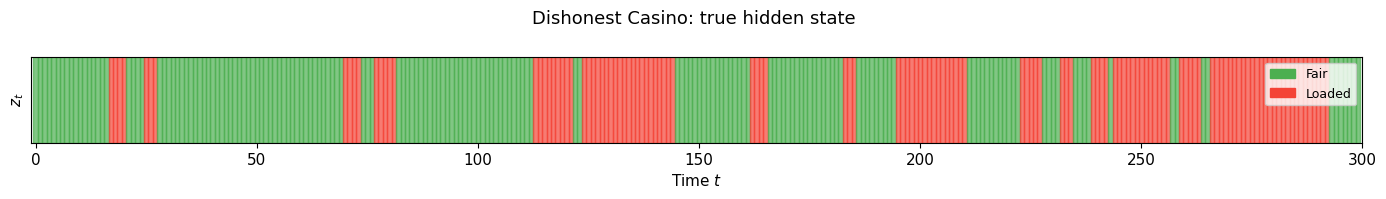

In [5]:
# Visualize: True hidden state
fig, ax = plt.subplots(1, 1, figsize=(14, 2), sharex=True)
colors = ['#4CAF50', '#F44336']
for t in range(T):
    ax.axvspan(t-0.5, t+0.5, color=colors[true_states[t]], alpha=0.7)
ax.set_yticks([])
ax.set_ylabel('$z_t$')
ax.legend(handles=[mpatches.Patch(color=colors[0], label='Fair'),
                         mpatches.Patch(color=colors[1], label='Loaded')],
               loc='upper right', fontsize=9)

ax.set_xlabel('Time $t$')
ax.set_xlim(-1, T)
fig.suptitle('Dishonest Casino: true hidden state', fontsize=13)
plt.tight_layout()
plt.show()

Notice: during loaded segments, 6s appear more frequently, but this pattern is not directly observable. We need the HMM machinery to infer $z_t$.

Formal definition oh an HMM.

- **Latent states** $z_t \in \{1, \dots, K\}$
- **Observations** $x_t \in \{1, \dots, 6\}$
- **Transition matrix** $A$ with $a_{ij} = p(z_t = j \mid z_{t-1} = i)$
- **Initial distribution** $\pi$ with $\pi_i = p(z_1 = i)$
- **Emission parameters** $B$, so that $p(x_t \mid z_t, B)$
- **Full parameters** $\Theta = (A, \pi, B)$

Joint factorization:

$$p(x, z \mid \Theta) = p(z_1 \mid \pi) \prod_{t=2}^{T} p(z_t \mid z_{t-1}, A) \prod_{t=1}^{T} p(x_t \mid z_t, B)$$

---
## 2. Core HMM Algorithms

We convert the HMM Bayes net into a factor graph (chain):

$$\tilde{f}_1(z_1) = p(z_1)p(x_1|z_1), \quad f_t(z_{t-1}, z_t) = p(z_t|z_{t-1})p(x_t|z_t)$$

with $x_t$ clamped (observed).

### 2.1 Forward Algorithm

Compute $\alpha(z_t) := p(z_t, x_{1:t})$ via:

$$\alpha(z_1) = p(z_1) \, p(x_1|z_1) = \pi_{z_1} \, p(x_1|z_1)$$
$$\alpha(z_t) = \sum_{z_{t-1}} A_{z_{t-1}, z_t} \, p(x_t|z_t) \, \alpha(z_{t-1})$$

**Filtering** at time $T$: $\;p(z_T | x_{1:T}) = \frac{p(z_T, x_{1:T})}{p(x_{1:T})} = \frac{\alpha(z_T)}{\sum_{z_T} \alpha(z_T)}$

In [6]:
def forward(A, pi, B, obs):
    """Forward algorithm. Returns alpha (T x K) and scaling factors c (T,)."""
    T = len(obs)
    K = len(pi)
    alpha = np.zeros((T, K))
    c = np.zeros(T)  # scaling to avoid underflow

    alpha[0] = pi * B[:, obs[0]]
    c[0] = alpha[0].sum()
    alpha[0] /= c[0]

    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum()
        alpha[t] /= c[t]

    return alpha, c

alpha, c = forward(A_casino, pi_casino, B_casino, observations)
log_likelihood = np.sum(np.log(c))
print(f"log p(x|Θ) = {log_likelihood:.2f}")
print(f"Filtered p(z_T=Loaded | x) = {alpha[-1, 1]:.4f}")

log p(x|Θ) = -502.04
Filtered p(z_T=Loaded | x) = 0.0786


### 2.2 Backward Algorithm

Compute $\beta(z_t) := p(x_{t+1 \, :\, T} | z_t)$ via:

$$\beta(z_T) = 1$$
$$\beta(z_t) = \sum_{z_{t+1}} A_{z_t, z_{t+1}} \, p(x_{t+1}|z_{t+1}) \, \beta(z_{t+1})$$

In [7]:
def backward(A, B, obs, c):
    """Backward algorithm (using same scaling factors from forward)."""
    T = len(obs)
    K = A.shape[0]
    beta = np.zeros((T, K))
    beta[-1] = 1.0

    for t in range(T-2, -1, -1):
        beta[t] = A @ (B[:, obs[t+1]] * beta[t+1])
        beta[t] /= c[t+1]

    return beta

beta = backward(A_casino, B_casino, observations, c)

### 2.3 Smoothing (Forward-Backward)

$$ p(z_t, x_{1,T}) = p(x_{t+1,T}| z_t, x_{1,t})p(z_t, x_{1,t}) = p(x_{t+1,T}| z_t)p(z_t, x_{1,t})  $$

Substituting:

$$\gamma(z_t) := p(z_t | x_{1:T}) \propto p(z_t, x_{1:t}) p(x_{t+1:T}|z_t) = \alpha(z_t)\,\beta(z_t)$$

And the pairwise marginals:

$$\xi(z_t, z_{t+1}) := p(z_t, z_{t+1} | x_{1:T}) \propto \alpha(z_t)\,A_{z_t,z_{t+1}}\,p(x_{t+1}|z_{t+1})\,\beta(z_{t+1})$$

In [8]:
def forward_backward(A, pi, B, obs):
    """Full forward-backward. Returns gamma (T,K), xi (T-1,K,K), log-likelihood."""
    alpha, c = forward(A, pi, B, obs)
    beta = backward(A, B, obs, c)
    T, K = alpha.shape

    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)

    xi = np.zeros((T-1, K, K))
    for t in range(T-1):
        xi[t] = np.outer(alpha[t], B[:, obs[t+1]] * beta[t+1]) * A
        xi[t] /= xi[t].sum()

    ll = np.sum(np.log(c))
    return gamma, xi, ll

gamma, xi, ll = forward_backward(A_casino, pi_casino, B_casino, observations)
print(f"log p(x|Θ) = {ll:.2f}")

log p(x|Θ) = -502.04


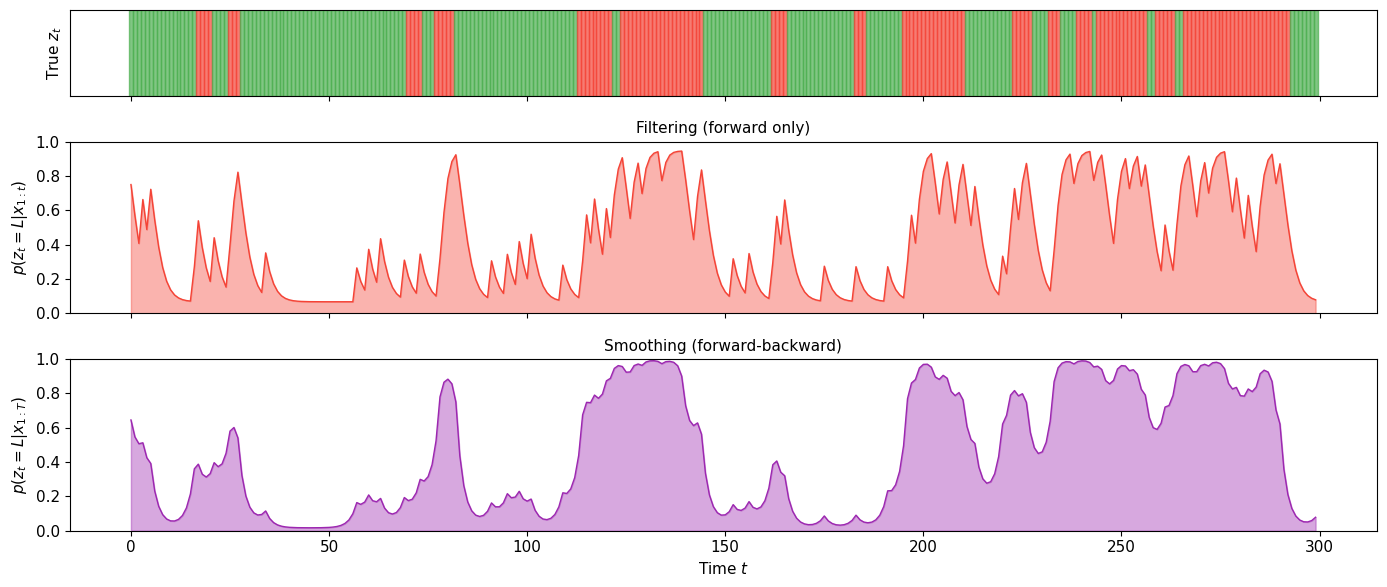

In [ ]:
# --- Plot: Filtering vs Smoothing ---
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={'height_ratios': [1, 2, 2]})

# True state
for t in range(T):
    axes[0].axvspan(t-0.5, t+0.5, color=colors[true_states[t]], alpha=0.7)
axes[0].set_yticks([]); axes[0].set_ylabel('True $z_t$')

# Filtering: p(z_t | x_{1:t})
axes[1].fill_between(range(T), alpha[:, 1], alpha=0.4, color='#F44336')
axes[1].plot(range(T), alpha[:, 1], color='#F44336', lw=1)
axes[1].set_ylabel('$p(z_t=L|x_{1:t})$')
axes[1].set_title('Filtering (forward only)', fontsize=11)
axes[1].set_ylim(0, 1)

# Smoothing: p(z_t | x_{1:T})
axes[2].fill_between(range(T), gamma[:, 1], alpha=0.4, color='#9C27B0')
axes[2].plot(range(T), gamma[:, 1], color='#9C27B0', lw=1)
axes[2].set_ylabel('$p(z_t=L|x_{1:T})$')
axes[2].set_title('Smoothing (forward-backward)', fontsize=11)
axes[2].set_ylim(0, 1)
axes[2].set_xlabel('Time $t$')

plt.tight_layout()
plt.show()

**Key observation:** Smoothing uses future evidence too, producing sharper, more confident estimates than filtering.

### 2.4 Viterbi Algorithm (Most Likely Explanation)

Given $x_1, \dots, x_T$.

Find $z^* = \arg\max_z p(z|x)$ via max-plus on the factor graph:

$$\delta_t(j) = \max_{z_{t-1}} \big[\log a_{z_{t-1},j} + \log p(x_t|j) + \delta_{t-1}(z_{t-1})\big]$$
$$\psi_t(j) = \arg\max_{z_{t-1}} \big[\log a_{z_{t-1},j} + \delta_{t-1}(z_{t-1})\big]$$

Then backtrack from $z_T^* = \arg\max_j \delta_T(j)$.




In [9]:
def viterbi(A, pi, B, obs):
    """Viterbi decoding. Returns best state sequence and log-probability."""
    T = len(obs)
    K = len(pi)
    log_A = np.log(A + 1e-300)
    log_B = np.log(B + 1e-300)
    log_pi = np.log(pi + 1e-300)

    delta = np.zeros((T, K))
    psi = np.zeros((T, K), dtype=int)

    delta[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for j in range(K):
            scores = delta[t-1] + log_A[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + log_B[j, obs[t]]

    # Backtrack
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(delta[-1])
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]

    return path, delta[-1].max()

viterbi_path, viterbi_logp = viterbi(A_casino, pi_casino, B_casino, observations)
accuracy = (viterbi_path == true_states).mean()
print(f"Viterbi accuracy: {accuracy:.2%}")

Viterbi accuracy: 83.00%


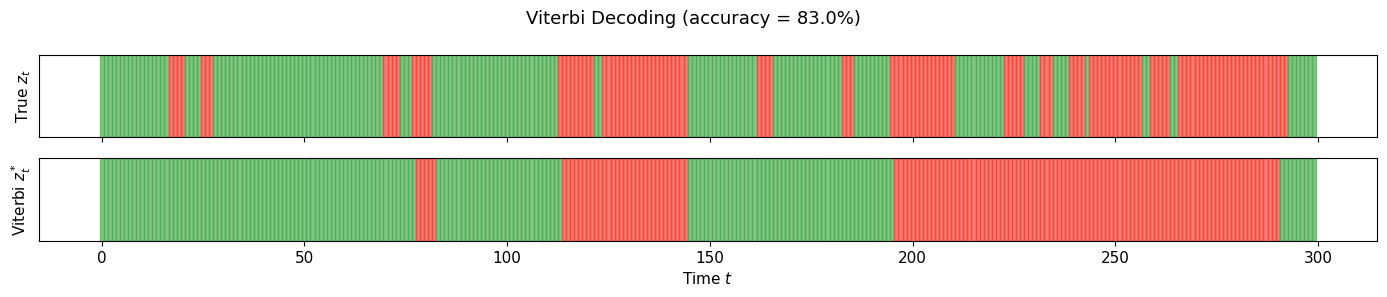

In [10]:
# --- Plot: Viterbi vs True States ---
fig, axes = plt.subplots(2, 1, figsize=(14, 3), sharex=True)

for t in range(T):
    axes[0].axvspan(t-0.5, t+0.5, color=colors[true_states[t]], alpha=0.7)
    axes[1].axvspan(t-0.5, t+0.5, color=colors[viterbi_path[t]], alpha=0.7)

axes[0].set_yticks([]); axes[0].set_ylabel('True $z_t$')
axes[1].set_yticks([]); axes[1].set_ylabel('Viterbi $z_t^*$')
axes[1].set_xlabel('Time $t$')
fig.suptitle(f'Viterbi Decoding (accuracy = {accuracy:.1%})', fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 Trellis Diagram

The Viterbi algorithm traces the optimal path through a **trellis** — a grid of (state, time) nodes with transition edges.

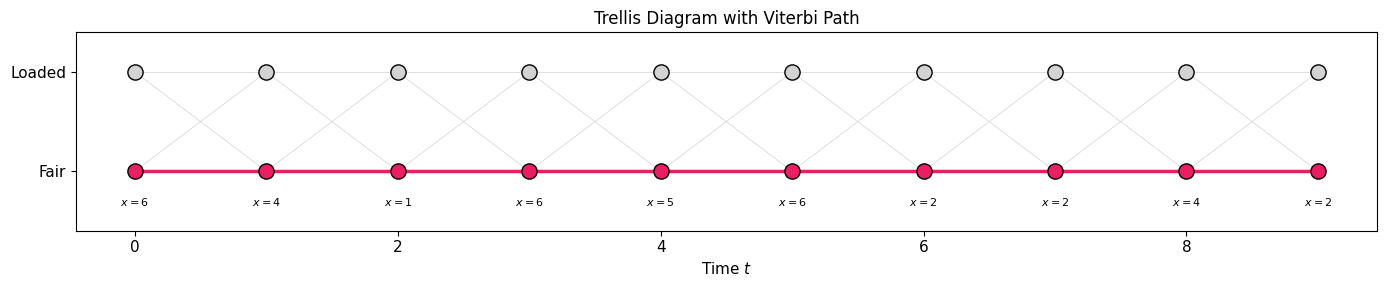

In [11]:
# --- Trellis diagram for a short subsequence ---
T_trellis = 10
sub_obs = observations[:T_trellis]
sub_path, _ = viterbi(A_casino, pi_casino, B_casino, sub_obs)

fig, ax = plt.subplots(figsize=(14, 3))
state_labels = ['Fair', 'Loaded']
K = 2

# Draw all edges (light)
for t in range(T_trellis - 1):
    for i in range(K):
        for j in range(K):
            ax.plot([t, t+1], [i, j], 'lightgray', lw=0.5, zorder=1)

# Draw Viterbi path (bold)
for t in range(T_trellis - 1):
    ax.plot([t, t+1], [sub_path[t], sub_path[t+1]],
            color='#E91E63', lw=2.5, zorder=2)

# Draw nodes
for t in range(T_trellis):
    for k in range(K):
        c = '#E91E63' if sub_path[t] == k else 'lightgray'
        ax.scatter(t, k, s=120, c=c, edgecolors='black', zorder=3)
    ax.text(t, -0.35, f'$x={sub_obs[t]+1}$', ha='center', fontsize=8)

ax.set_yticks([0, 1]); ax.set_yticklabels(state_labels)
ax.set_xlabel('Time $t$')
ax.set_title('Trellis Diagram with Viterbi Path', fontsize=12)
ax.set_ylim(-0.6, 1.4)
plt.tight_layout()
plt.show()

### 2.6 Parameter Learning: Baum-Welch (EM)

Given observations $x_{1:T}$, learn $\Theta = (A, \pi, B)$ by maximizing $\log p(x|\Theta)$.

**E-step:** Run forward-backward to get $\gamma_t(i)$ and $\xi_t(i,j)$.

**M-step:**
$$\hat{\pi}_i = \gamma_1(i)$$
$$\hat{a}_{ij} = \frac{\sum_{t=1}^{T-1} \xi_t(i,j)}{\sum_{t=1}^{T-1} \gamma_t(i)}$$
$$\hat{b}_i(k) = \frac{\sum_{t: x_t=k} \gamma_t(i)}{\sum_{t=1}^{T} \gamma_t(i)}$$

In [12]:
def baum_welch(obs, K, n_obs, max_iter=100, tol=1e-6):
    """Baum-Welch EM for discrete HMM. Returns learned (A, pi, B) and log-likelihood history."""
    T = len(obs)

    # Random initialization
    A = np.random.dirichlet(np.ones(K), size=K)
    pi = np.random.dirichlet(np.ones(K))
    B = np.random.dirichlet(np.ones(n_obs), size=K)

    ll_history = []

    for it in range(max_iter):
        # E-step
        gamma, xi, ll = forward_backward(A, pi, B, obs)
        ll_history.append(ll)

        if it > 0 and abs(ll - ll_history[-2]) < tol:
            break

        # M-step
        pi = gamma[0]

        for i in range(K):
            denom = gamma[:-1, i].sum()
            for j in range(K):
                A[i, j] = xi[:, i, j].sum() / (denom + 1e-300)
            for k in range(n_obs):
                B[i, k] = gamma[obs == k, i].sum() / (gamma[:, i].sum() + 1e-300)

    return A, pi, B, ll_history

In [13]:
# Learn parameters from observations only (no knowledge of true states)
A_learned, pi_learned, B_learned, ll_hist = baum_welch(observations, K=2, n_obs=6, max_iter=200)

print("Learned transition matrix A:")
print(np.round(A_learned, 3))
print(f"\nTrue A:\n{A_casino}")
print(f"\nLearned emission B:\n{np.round(B_learned, 3)}")
print(f"\nTrue B:\n{np.round(B_casino, 3)}")

Learned transition matrix A:
[[0.959 0.041]
 [0.028 0.972]]

True A:
[[0.95 0.05]
 [0.1  0.9 ]]

Learned emission B:
[[0.114 0.054 0.063 0.116 0.099 0.554]
 [0.191 0.191 0.124 0.19  0.125 0.179]]

True B:
[[0.167 0.167 0.167 0.167 0.167 0.167]
 [0.1   0.1   0.1   0.1   0.1   0.5  ]]


<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_26448/603667685.py:5: SyntaxWarning: invalid escape sequence '\,'
  ax.set_ylabel('$\\log\, p(x|\\Theta)$')


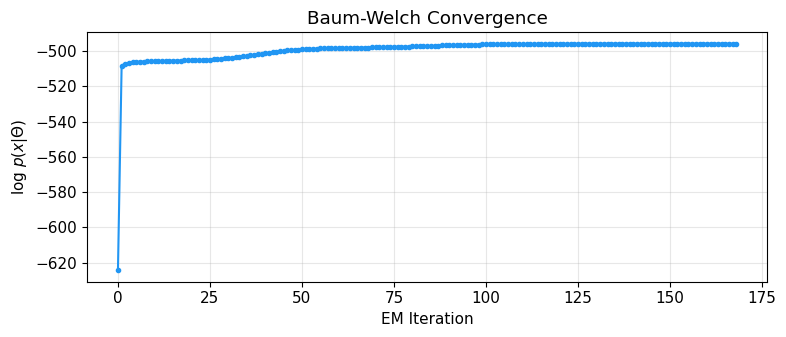

In [14]:
# --- Plot: EM convergence ---
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ll_hist, 'o-', markersize=3, color='#2196F3')
ax.set_xlabel('EM Iteration')
ax.set_ylabel('$\\log\, p(x|\\Theta)$')
ax.set_title('Baum-Welch Convergence')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Model Selection

How many hidden states $K$? We use information criteria:

$$\text{BIC} = -2\,\log p(x|\hat{\Theta}) + d\,\log T$$
$$\text{AIC} = -2\,\log p(x|\hat{\Theta}) + 2d$$

where $d = K^2 + K \cdot M - 1$ is the number of free parameters ($M$ = number of observation symbols). Lower is better.

In [15]:
def count_params(K, M):
    """Free parameters: K*(K-1) transitions + K*(M-1) emissions + (K-1) initial."""
    return K*(K-1) + K*(M-1) + (K-1)

results = []
for K in range(1, 6):
    best_ll = -np.inf
    for trial in range(5):  # multiple restarts
        _, _, _, ll_h = baum_welch(observations, K=K, n_obs=6, max_iter=200)
        if ll_h[-1] > best_ll:
            best_ll = ll_h[-1]
    d = count_params(K, 6)
    bic = -2*best_ll + d*np.log(T)
    aic = -2*best_ll + 2*d
    results.append((K, best_ll, bic, aic, d))
    print(f"K={K}: log L = {best_ll:.1f}, BIC = {bic:.1f}, AIC = {aic:.1f} (d={d})")

K=1: log L = -505.8, BIC = 1040.1, AIC = 1021.6 (d=5)
K=2: log L = -495.8, BIC = 1065.8, AIC = 1017.7 (d=13)
K=3: log L = -492.2, BIC = 1115.6, AIC = 1030.4 (d=23)
K=4: log L = -483.8, BIC = 1167.1, AIC = 1037.5 (d=35)
K=5: log L = -480.3, BIC = 1240.1, AIC = 1058.6 (d=49)


<>:5: SyntaxWarning: invalid escape sequence '\,'
<>:5: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_26448/3743574007.py:5: SyntaxWarning: invalid escape sequence '\,'
  axes[0].set_xlabel('$K$ (number of states)'); axes[0].set_ylabel('$\\log\, p(x|\\hat{\\Theta})$')


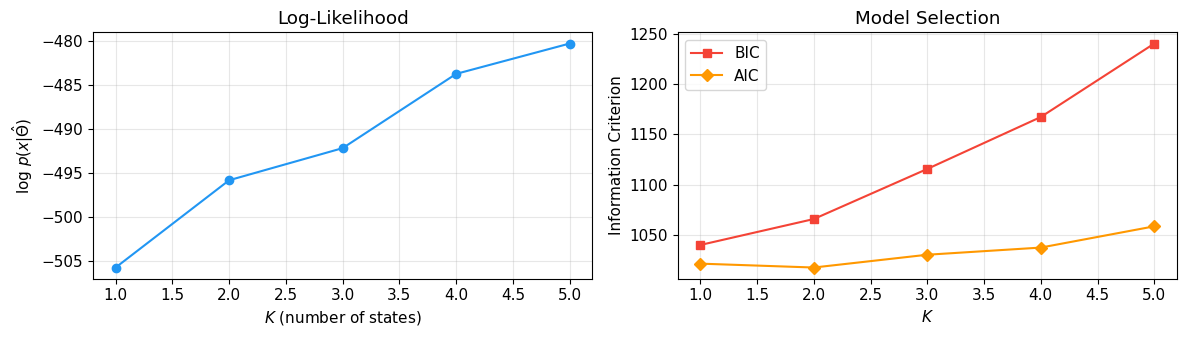

Best K by BIC: 1
Best K by AIC: 2


In [16]:
Ks, lls, bics, aics, _ = zip(*results)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(Ks, lls, 'o-', color='#2196F3')
axes[0].set_xlabel('$K$ (number of states)'); axes[0].set_ylabel('$\\log\, p(x|\\hat{\\Theta})$')
axes[0].set_title('Log-Likelihood'); axes[0].grid(alpha=0.3)

axes[1].plot(Ks, bics, 's-', label='BIC', color='#F44336')
axes[1].plot(Ks, aics, 'D-', label='AIC', color='#FF9800')
axes[1].set_xlabel('$K$'); axes[1].set_ylabel('Information Criterion')
axes[1].set_title('Model Selection'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Best K by BIC: {Ks[np.argmin(bics)]}")
print(f"Best K by AIC: {Ks[np.argmin(aics)]}")

---
## Summary

| Problem | Algorithm | Complexity |
|---|---|---|
| $p(z_T \mid x_{1:T})$ (Filtering) | Forward | $O(TK^2)$ |
| $p(z_t \mid x_{1:T})$ (Smoothing) | Forward-Backward | $O(TK^2)$ |
| $\arg\max_z p(z \mid x)$ (Decoding) | Viterbi | $O(TK^2)$ |


The **factor graph** view unifies everything: forward messages are sum-product from left, backward from right, Viterbi is max-plus.